In [3]:
# 1. Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

In [4]:
# Ajuste o caminho caso o notebook esteja em outra pasta
url = 'https://docs.google.com/spreadsheets/d/1Ou9RFvSBZHRtVLkEi45qsjfY8aB4dT1bYFz-cdeuwFw/export?format=xlsx'

df = pd.read_excel(url)
print(df.shape)
df.head()

(22, 12)


,Carimbo de data/hora,nome,area,gerente,empresa,CSAT,faturamento,colaborativo,impacto,início,fim estimado,situacao
0,2026-09-21 15:31:26.000,Projeto Eclipse,Sites,Gustavo Ramos,Órbita Dev,NaN,30000,30000,0,2026-10-23,2026-11-23,Em andamento
1,2026-08-29 18:07:03.613,Projeto Arthur,Dados,Italo Dias,TCAR,NaN,5000,5000,0,2026-10-15,2026-11-15,Iniciado
2,2026-08-29 18:55:36.565,Projeto ASURA,Dados,italo Dias,Empresa x,NaN,4000,0,0,2026-10-07,2026-11-07,Iniciado
3,2026-09-23 15:31:26.000,Projeto Quasar,Dados,Beatriz Nunes,Prisma Digital,NaN,2000,0,0,2026-08-10,2026-09-10,Iniciado
4,2026-09-17 15:31:26.000,Projeto Fênix,Mobile,Pedro de Pádua,Jagger CO,NaN,10000,0,1,2026-06-10,2026-07-10,Em andamento


In [5]:
mapa_colunas = {
    'Carimbo de data/hora': 'data_registro',                      # timestamp do formulário
    'nome': 'nome_projeto',
    'area': 'area',                                # dados / mobile / desktop / sites
    'gerente': 'responsavel',
    'empresa': 'cliente',
    'CSAT': 'satisfacao',
    'faturamento': 'valor_total_projeto',                 # valor contratado do projeto
    'colaborativo': 'valor_faturamento_colaborativo',     # valor faturado em parceria com outra empresa
    'impacto': 'projeto_de_impacto',                  # 0/1 -> binário para previsão futura
    'início': 'data_inicio',
    'fim estimado': 'data_fim',
    'situacao': 'status',                             # concluído / em andamento / iniciado
}

def padronizar_colunas(df, mapa=mapa_colunas):
    """Renomeia as colunas e avisa se alguma coluna esperada não veio na fonte (ex.: pergunta removida do Forms)."""
    colunas_ausentes = [c for c in mapa if c not in df.columns]
    if colunas_ausentes:
        print(f'[aviso] colunas esperadas não encontradas na fonte: {colunas_ausentes}')
    return df.rename(columns=mapa)

df = df.rename(columns=mapa_colunas)
df.head()


,data_registro,nome_projeto,area,responsavel,cliente,satisfacao,valor_total_projeto,valor_faturamento_colaborativo,projeto_de_impacto,data_inicio,data_fim,status
0,2026-09-21 15:31:26.000,Projeto Eclipse,Sites,Gustavo Ramos,Órbita Dev,NaN,30000,30000,0,2026-10-23,2026-11-23,Em andamento
1,2026-08-29 18:07:03.613,Projeto Arthur,Dados,Italo Dias,TCAR,NaN,5000,5000,0,2026-10-15,2026-11-15,Iniciado
2,2026-08-29 18:55:36.565,Projeto ASURA,Dados,italo Dias,Empresa x,NaN,4000,0,0,2026-10-07,2026-11-07,Iniciado
3,2026-09-23 15:31:26.000,Projeto Quasar,Dados,Beatriz Nunes,Prisma Digital,NaN,2000,0,0,2026-08-10,2026-09-10,Iniciado
4,2026-09-17 15:31:26.000,Projeto Fênix,Mobile,Pedro de Pádua,Jagger CO,NaN,10000,0,1,2026-06-10,2026-07-10,Em andamento


In [6]:
df['projeto_de_impacto'] = df['projeto_de_impacto'].astype(bool)
df['status'] = df['status'].str.strip()
df['area'] = df['area'].str.strip()

print('Linhas duplicadas:', df.duplicated().sum())
print()
print('Valores nulos por coluna:')
print(df.isna().sum())
print()
print('Categorias de área:', df['area'].unique())
print('Categorias de status:', df['status'].unique())

Linhas duplicadas: 0

Valores nulos por coluna:
data_registro                      0
nome_projeto                       0
area                               0
responsavel                        0
cliente                            0
satisfacao                        22
valor_total_projeto                0
valor_faturamento_colaborativo     0
projeto_de_impacto                 0
data_inicio                        0
data_fim                           0
status                             0
dtype: int64

Categorias de área: <StringArray>
['Sites', 'Dados', 'Mobile', 'Desktop']
Length: 4, dtype: str
Categorias de status: <StringArray>
['Em andamento', 'Iniciado', 'Concluído']
Length: 3, dtype: str


In [7]:
def limpar_dados(df):
    df = df.copy()
    df['projeto_de_impacto'] = df['projeto_de_impacto'].fillna(0).astype(int).astype(bool)
    df['status'] = df['status'].astype(str).str.strip()
    df['area'] = df['area'].astype(str).str.strip()

    # --- Tratamento da coluna CSAT (satisfacao) ---
    df['satisfacao'] = pd.to_numeric(df['satisfacao'], errors='coerce')
    fora_da_escala = df['satisfacao'].notna() & ~df['satisfacao'].between(0, 10)
    if fora_da_escala.any():
        print(f'[atenção] {fora_da_escala.sum()} valor(es) de CSAT fora da escala 0-10 foram descartados.')
        df.loc[fora_da_escala, 'satisfacao'] = np.nan

    concluido_sem_csat = (df['status'] == 'Concluído') & df['satisfacao'].isna()
    nao_concluido_com_csat = (df['status'] != 'Concluído') & df['satisfacao'].notna()
    print(f'Projetos concluídos sem CSAT registrado: {concluido_sem_csat.sum()}')
    print(f'Projetos não concluídos com CSAT já registrado (incomum, revisar): {nao_concluido_com_csat.sum()}')

    print('\nLinhas duplicadas:', df.duplicated().sum())
    print('\nValores nulos por coluna:')
    print(df.isna().sum())
    print('\nCategorias de área:', df['area'].unique())
    print('Categorias de status:', df['status'].unique())
    return df

df = limpar_dados(df)


Projetos concluídos sem CSAT registrado: 15
Projetos não concluídos com CSAT já registrado (incomum, revisar): 0

Linhas duplicadas: 0

Valores nulos por coluna:
data_registro                      0
nome_projeto                       0
area                               0
responsavel                        0
cliente                            0
satisfacao                        22
valor_total_projeto                0
valor_faturamento_colaborativo     0
projeto_de_impacto                 0
data_inicio                        0
data_fim                           0
status                             0
dtype: int64

Categorias de área: <StringArray>
['Sites', 'Dados', 'Mobile', 'Desktop']
Length: 4, dtype: str
Categorias de status: <StringArray>
['Em andamento', 'Iniciado', 'Concluído']
Length: 3, dtype: str


In [8]:
df['ano_inicio'] = df['data_inicio'].dt.year
df['mes_inicio'] = df['data_inicio'].dt.month
df['ano_mes_inicio'] = df['data_inicio'].dt.to_period('M').astype(str)
df['duracao_dias'] = (df['data_fim'] - df['data_inicio']).dt.days

df[['nome_projeto', 'data_inicio', 'data_fim', 'duracao_dias', 'ano_mes_inicio']].head()


,nome_projeto,data_inicio,data_fim,duracao_dias,ano_mes_inicio
0,Projeto Eclipse,2026-10-23,2026-11-23,31,2026-10
1,Projeto Arthur,2026-10-15,2026-11-15,31,2026-10
2,Projeto ASURA,2026-10-07,2026-11-07,31,2026-10
3,Projeto Quasar,2026-08-10,2026-09-10,31,2026-08
4,Projeto Fênix,2026-06-10,2026-07-10,30,2026-06


/tmp/ipykernel_567/2057925987.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(faturamento_mensal['ano_mes_inicio'], rotation=45, ha='right')


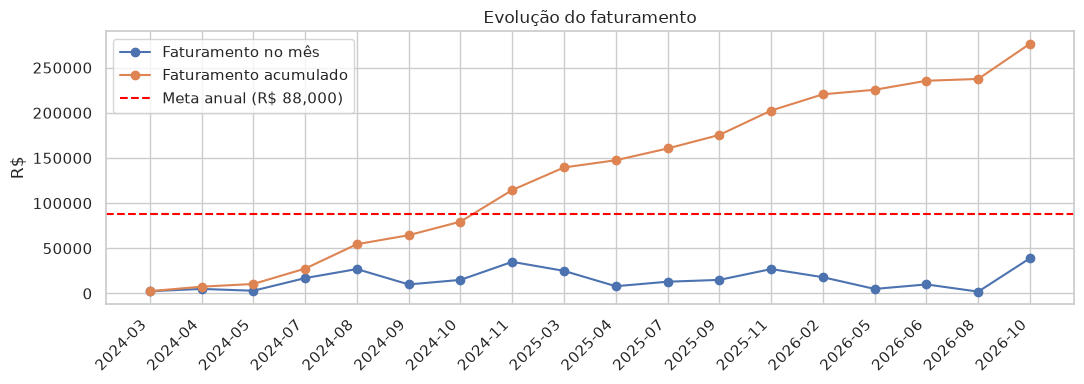

,ano_mes_inicio,valor_total_projeto,faturamento_acumulado
0,2024-03,2500,2500
1,2024-04,5000,7500
2,2024-05,3000,10500
3,2024-07,17000,27500
4,2024-08,27000,54500
5,2024-09,10000,64500
6,2024-10,15000,79500
7,2024-11,35000,114500
8,2025-03,25000,139500
9,2025-04,8000,147500


In [ ]:
META_ANUAL = 88000
META_COLABORATIVA = 70000

faturamento_mensal = (
    df.groupby('ano_mes_inicio', as_index=False)['valor_total_projeto']
      .sum()
      .sort_values('ano_mes_inicio')
      .reset_index(drop=True)
)
faturamento_mensal['faturamento_acumulado'] = faturamento_mensal['valor_total_projeto'].cumsum()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(faturamento_mensal['ano_mes_inicio'], faturamento_mensal['valor_total_projeto'],
        marker='o', label='Faturamento no mês')
ax.plot(faturamento_mensal['ano_mes_inicio'], faturamento_mensal['faturamento_acumulado'],
        marker='o', label='Faturamento acumulado')
ax.axhline(META_ANUAL, color='red', linestyle='--', label=f'Meta anual (R$ {META_ANUAL:,.0f})')
ax.set_xticklabels(faturamento_mensal['ano_mes_inicio'], rotation=45, ha='right')
ax.set_ylabel('R$')
ax.set_title('Evolução do faturamento')
ax.legend()
plt.tight_layout()
plt.show()

faturamento_mensal


In [12]:
def criar_atributos_temporais(df):
    df = df.copy()
    df['ano_inicio'] = df['data_inicio'].dt.year
    df['mes_inicio'] = df['data_inicio'].dt.month
    df['ano_mes_inicio'] = df['data_inicio'].dt.to_period('M').astype(str)
    df['duracao_dias'] = (df['data_fim'] - df['data_inicio']).dt.days

    inconsistente = df['valor_faturamento_colaborativo'] > df['valor_total_projeto']
    if inconsistente.any():
        print(f'[atenção] {inconsistente.sum()} projeto(s) com faturamento colaborativo maior que o total — revisar na fonte.')

    df['valor_faturamento_proprio'] = (df['valor_total_projeto'] - df['valor_faturamento_colaborativo']).clip(lower=0)
    return df

df = criar_atributos_temporais(df)
df[['nome_projeto', 'valor_total_projeto', 'valor_faturamento_colaborativo', 'valor_faturamento_proprio', 'ano_mes_inicio']].head()


,nome_projeto,valor_total_projeto,valor_faturamento_colaborativo,valor_faturamento_proprio,ano_mes_inicio
0,Projeto Eclipse,30000,30000,0,2026-10
1,Projeto Arthur,5000,5000,0,2026-10
2,Projeto ASURA,4000,0,4000,2026-10
3,Projeto Quasar,2000,0,2000,2026-08
4,Projeto Fênix,10000,0,10000,2026-06


In [10]:
cluster_base = df.groupby('ano_mes_inicio').agg(
    faturamento_total=('valor_total_projeto', 'sum'),
    faturamento_colaborativo=('valor_faturamento_colaborativo', 'sum'),
    qtd_projetos=('nome_projeto', 'count'),
    qtd_projetos_impacto=('projeto_de_impacto', 'sum'),
    qtd_projetos_concluidos=('status', lambda s: (s == 'Concluído').sum()),
).reset_index()

cluster_base['pct_projetos_impacto'] = cluster_base['qtd_projetos_impacto'] / cluster_base['qtd_projetos']
cluster_base


,ano_mes_inicio,faturamento_total,faturamento_colaborativo,qtd_projetos,qtd_projetos_impacto,qtd_projetos_concluidos,pct_projetos_impacto
0,2024-03,2500,0,1,0,1,0.0
1,2024-04,5000,5000,1,0,1,0.0
2,2024-05,3000,0,1,0,1,0.0
3,2024-07,17000,0,1,0,1,0.0
4,2024-08,27000,20000,2,0,2,0.0
5,2024-09,10000,0,1,0,1,0.0
6,2024-10,15000,0,1,0,1,0.0
7,2024-11,35000,35000,1,1,1,1.0
8,2025-03,25000,25000,1,0,1,0.0
9,2025-04,8000,0,1,0,1,0.0


In [11]:
colunas_numericas = [
    'faturamento_total',
    'faturamento_colaborativo',
    'qtd_projetos',
    'qtd_projetos_impacto',
    'pct_projetos_impacto',
]

scaler = StandardScaler()
cluster_base_scaled = cluster_base.copy()
cluster_base_scaled[colunas_numericas] = scaler.fit_transform(cluster_base[colunas_numericas])
cluster_base_scaled


,ano_mes_inicio,faturamento_total,faturamento_colaborativo,qtd_projetos,qtd_projetos_impacto,qtd_projetos_concluidos,pct_projetos_impacto
0,2024-03,-1.177629,-0.772499,-0.417029,-0.447214,1,-0.427179
1,2024-04,-0.948716,-0.370621,-0.417029,-0.447214,1,-0.427179
2,2024-05,-1.131847,-0.772499,-0.417029,-0.447214,1,-0.427179
3,2024-07,0.150065,-0.772499,-0.417029,-0.447214,1,-0.427179
4,2024-08,1.065716,0.835013,1.459601,-0.447214,2,-0.427179
5,2024-09,-0.490891,-0.772499,-0.417029,-0.447214,1,-0.427179
6,2024-10,-0.033065,-0.772499,-0.417029,-0.447214,1,-0.427179
7,2024-11,1.798237,2.040646,-0.417029,2.236068,1,2.648509
8,2025-03,0.882586,1.236891,-0.417029,-0.447214,1,-0.427179
9,2025-04,-0.674021,-0.772499,-0.417029,-0.447214,1,-0.427179
